# Absorption on Flat Surface

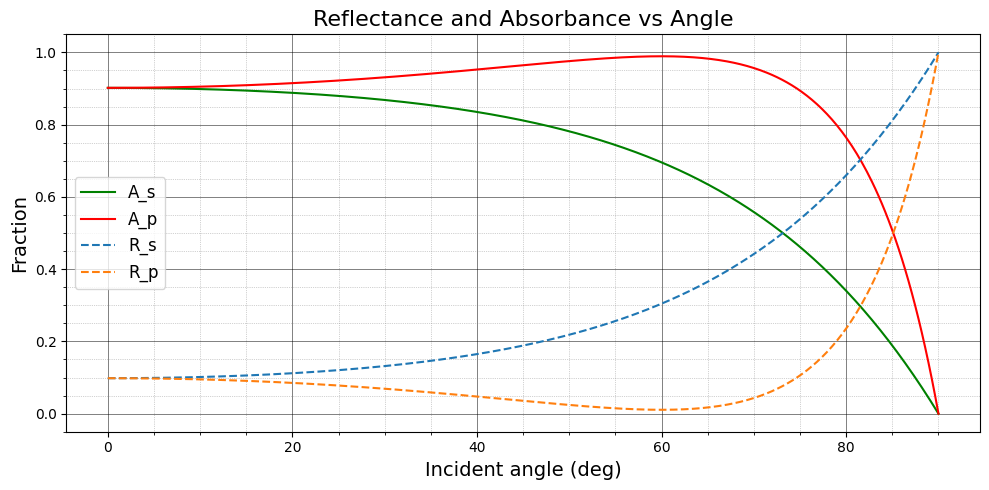

max difference at: 77.014


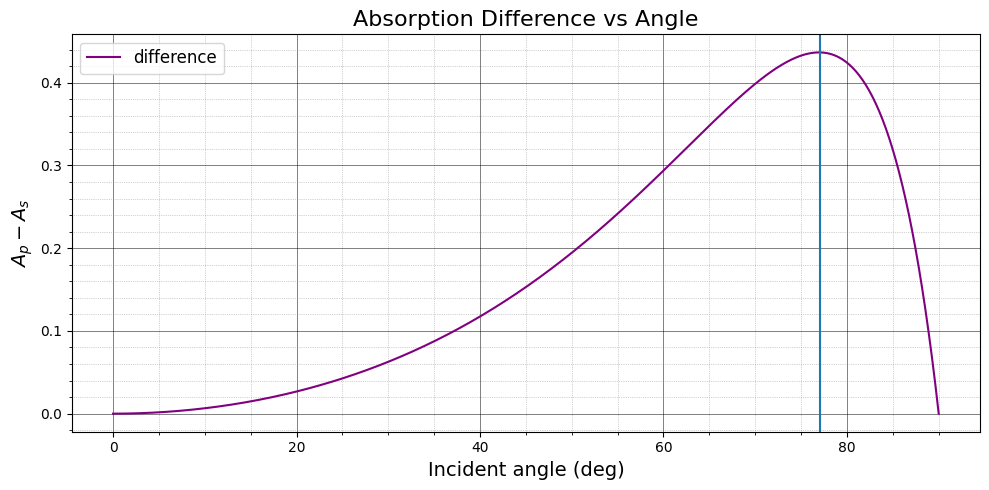

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

# print(plt.style.available)
#plt.style.use(['science', 'notebook', 'grid'])
plt.style.use(['default'])

wavelength = 0.64  # microns (640 nm)
d = 20.0           # thickness in microns

n0 = 1.0           # air
m = 1.7 + 0.5j     # from the 2012 paper
n2 = 1.0           # air

# absorption coefficient
alpha = 4 * np.pi * np.imag(m) / wavelength

angles_deg = np.linspace(0, 90, 500)

Rs_list = np.zeros(len(angles_deg))
Rp_list = Rs_list.copy()
As_list = Rs_list.copy()
Ap_list = Rs_list.copy()

for i, theta_deg in enumerate(angles_deg):
    theta_i = np.deg2rad(theta_deg)
    cos_i = np.cos(theta_i)
    sin_i = np.sin(theta_i)

    # complex Snell
    sin_t = (n0 / m) * sin_i
    cos_t = np.sqrt(1 - sin_t**2)

    # enforce physical branch
    if np.imag(cos_t) < 0:
        cos_t = -cos_t

    # Fresnel coefficients
    rs = (n0*cos_i - m*cos_t) / (n0*cos_i + m*cos_t)
    Rs = np.abs(rs)**2

    rp = (m*cos_i - n0*cos_t) / (m*cos_i + n0*cos_t)
    Rp = np.abs(rp)**2

    # attenuation
    path_factor = np.real(cos_t)
    if path_factor <= 0:
        path_factor = 1e-12

    attenuation = np.exp(-alpha * d / path_factor)

    Ts = (1 - Rs)**2 * attenuation
    Tp = (1 - Rp)**2 * attenuation

    As = 1 - Rs - Ts
    Ap = 1 - Rp - Tp

    Rs_list[i] = Rs
    Rp_list[i] = Rp
    As_list[i] = As
    Ap_list[i] = Ap

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(angles_deg, As_list, 'g' , label='A_s')
ax.plot(angles_deg, Ap_list, 'r' ,label='A_p')
ax.plot(angles_deg, Rs_list, '--', label='R_s')
ax.plot(angles_deg, Rp_list, '--',label='R_p')

ax.set_xlabel('Incident angle (deg)', fontsize=14)
ax.set_ylabel('Fraction', fontsize=14)
ax.set_title('Reflectance and Absorbance vs Angle', fontsize=16)
ax.legend(fontsize=12)

ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.7, color="black", alpha=0.5)
ax.grid(which="minor", linestyle=":", linewidth=0.5, color="gray", alpha=0.7)

fig.tight_layout()
#fig.savefig(fr"A:\Sem 10\Fresnal Model Diagram 1.png", dpi=500, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(10,5))

A_diff = Ap_list - As_list
ax2.plot(angles_deg, A_diff, color='purple', label='difference')
A_sum = Ap_list + As_list
#ax2.plot(angles_deg, A_sum, color='orange', label='sum')
C = A_diff / A_sum
#ax2.plot(angles_deg, C , color='blue', label='Ap-As/Ap+As')

# temp = Ap_list - As_list / (Ap_list + As_list)
# ax2.plot(angles_deg, temp, color='red', label='temp')

# dy_dx = np.gradient(C,angles_deg)
# ax2.plot(angles_deg, dy_dx, color='red', label='gradient')

x_peak = angles_deg[np.argmax(A_diff)]
ax2.axvline(x_peak)
print(f'max difference at: {x_peak:.3f}')

ax2.legend(fontsize=12)
ax2.set_xlabel('Incident angle (deg)', fontsize=14)
ax2.set_ylabel(r'$A_p - A_s$', fontsize=14)
ax2.set_title('Absorption Difference vs Angle', fontsize=16)

# ax2.set_ylabel(r'$(A_p - A_s)/(A_p + A_s)$', fontsize=14)
# ax2.set_title('Normalized Absorption Contrast vs Angle', fontsize=16)

ax2.minorticks_on()
ax2.grid(which="major", linestyle="-", linewidth=0.7, color="black", alpha=0.5)
ax2.grid(which="minor", linestyle=":", linewidth=0.5, color="gray", alpha=0.7)

fig2.tight_layout()
#fig2.savefig(fr"A:\Sem 10\Fresnal Model Diagram 2.png", dpi=500, bbox_inches="tight")
plt.show()

# Absorption Maps on the ellipsoid

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
import plotly.graph_objects as go
import imageio.v2 as imageio
import os

def load_parameters(particle, powers, base_dir=r"A:\LML\Images"):
    a_list, b_list, c_list, tx_list, ty_list = [], [], [], [], []

    def wrap_signed(angle_deg): # Forces angles into range [0, 90)
        angle = angle_deg % 180
        return min(angle, 180 - angle)

    for power in powers:
        json_path = fr"{base_dir}\{particle}\{particle}_{power}mW_parameters.json"
        if not os.path.exists(json_path):
            print(f"Missing file for {power}mW — skipping")
            continue
        with open(json_path, "r") as f:
            params = json.load(f)

        a_list.append(params["a_um"])
        b_list.append(params["b_um"])
        c_list.append(params["c_mean_um"])
        tx_list.append(wrap_signed(params["angle_xz_lab_deg"]))
        ty_list.append(wrap_signed(params["angle_yz_lab_deg"]))

    def circular_mean(angle_list): # just in case some angles are like [89, 2, 87, 5, 90]
        angles = np.deg2rad(angle_list)
        x, y = np.mean(np.cos(angles)), np.mean(np.sin(angles))
        return np.rad2deg(np.arctan2(y, x))

    return np.mean(a_list), np.mean(b_list), np.mean(c_list), circular_mean(tx_list), circular_mean(ty_list)

def reconstruct_c_axis_direction(theta_xz_deg, theta_yz_deg):
    tx, ty = np.deg2rad(theta_xz_deg), np.deg2rad(theta_yz_deg)
    # components of c vector
    cx = np.sin(tx)
    cy = np.sin(ty)
    cz = 0.5 * (np.cos(tx) + np.cos(ty))
    c_vec = np.array([cx, cy, cz])

    return c_vec / np.linalg.norm(c_vec) #unit vector

def rotation_from_body_z(vec): # Returns rotation matrix that rotates the body-z-axis onto the direction of 'vec'.
    body_z = np.array([0.0, 0.0, 1.0])
    v = vec / np.linalg.norm(vec)

    cross = np.cross(body_z, v) # axis of rotation
    s = np.linalg.norm(cross)
    c = np.dot(body_z, v)

    if s < 1e-12:
        return np.eye(3) # If already aligned, return identity

    # Skew-symmetric cross-product matrix
    vx = np.array([[0, -cross[2], cross[1]],
                   [cross[2], 0, -cross[0]],
                   [-cross[1], cross[0], 0]])

    R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s**2)) # Rodrigues formula
    return R

def generate_tilted_ellipsoid(a, b, c, theta_xz, theta_yz): # Generates Rotated surface points & Rotated outward unit normals
    theta = np.linspace(0, np.pi, 300)
    phi   = np.linspace(0, 2*np.pi, 600)
    TH, PH = np.meshgrid(theta, phi, indexing='ij')

    # Ellipsoid in its body frame
    x0 = a * np.sin(TH) * np.cos(PH)
    y0 = b * np.sin(TH) * np.sin(PH)
    z0 = c * np.cos(TH)

    nx0, ny0, nz0 = (2*x0)/(a**2), (2*y0)/(b**2), (2*z0)/(c**2) # Gradient of the ellipsoid surface
    norm = np.sqrt(nx0**2 + ny0**2 + nz0**2)
    nx0, ny0, nz0 = nx0/norm, ny0/norm, nz0/norm # unit gradient vectors of the surface

    # Fixing orientation
    c_hat = reconstruct_c_axis_direction(theta_xz, theta_yz)
    R = rotation_from_body_z(c_hat) # R @ z = c

    pts0 = np.stack([x0, y0, z0], axis=-1) # surface points
    pts = (R @ pts0.reshape(-1,3).T).T.reshape(pts0.shape) # Rotated surface points

    n0 = np.stack([nx0, ny0, nz0], axis=-1)
    n_hat = (R @ n0.reshape(-1,3).T).T.reshape(n0.shape) # Rotated normals

    return pts, n_hat, TH, PH # Rotated surface points, Rotated outward unit normals, parameter grids

def fresnel_abs(theta_i, n1):
    cos_i, sin_i = np.cos(theta_i), np.sin(theta_i)
    sin_t = (1/n1) * sin_i
    cos_t = np.sqrt(1 - sin_t**2) # NumPy automatically chooses the principal branch

    rs = (cos_i - n1*cos_t) / (cos_i + n1*cos_t)
    rp = (n1*cos_i - cos_t) / (n1*cos_i + cos_t)

    Rs, Rp = np.abs(rs)**2, np.abs(rp)**2

    return 1 - Rs, 1 - Rp # absorption coefficients for s and p polarization.

def compute_absorption_maps(a, b, c, theta_xz, theta_yz, E0):
    E0 = E0 / np.linalg.norm(E0)  # ensure unit field
    pts, n_hat, TH, PH = generate_tilted_ellipsoid(a, b, c, theta_xz, theta_yz) # Rotated surface, and outward unit normals, parameter grids

    #cos_i = -(n_hat @ k_hat) # Local incidence angle
    cos_i = -np.sum(n_hat * k_hat, axis=-1)

    bottom = cos_i > 0    # boolean mask to get illuminated side only
    theta_i = np.arccos(np.clip(cos_i, 0, 1))    # local incidence angle
    As_local, Ap_local = fresnel_abs(theta_i, n1)    # Fresnel absorption

    As_local[~bottom] = 0
    Ap_local[~bottom] = 0

    s_hat = np.cross(k_hat, n_hat)  # Local s plane
    s_norm = np.linalg.norm(s_hat, axis=-1, keepdims=True)
    s_hat = np.divide(s_hat, s_norm, out=np.zeros_like(s_hat), where=s_norm > 1e-10)
    
    # dealing with normal incidence point: Just one point, no issue if ignored.
    fallback = np.cross(k_hat, np.array([1.0,0.0,0.0]))
    fallback /= np.linalg.norm(fallback)
    normal_mask = (s_norm[...,0] < 1e-10)
    s_hat[normal_mask] = fallback

    p_hat = np.cross(s_hat, k_hat)  # Local p plane
    p_hat /= np.linalg.norm(p_hat, axis=-1, keepdims=True)

    # Electric field projections
    Es = np.abs(np.sum(E0 * s_hat, axis=-1))**2
    Ep = np.abs(np.sum(E0 * p_hat, axis=-1))**2

    A_total = Es * As_local + Ep * Ap_local # Total absorbed intensity
    A_total[~bottom] = 0

    return As_local, Ap_local, A_total, pts, TH, PH # Local and total absorptance maps

def surface_element(pts, TH, PH):
    dr_dtheta = np.gradient(pts, axis=0) # tangent along polar direction
    dr_dphi   = np.gradient(pts, axis=1) # tangent along azimuthal direction

    cross = np.cross(dr_dtheta, dr_dphi) # local surface element vector
    dS = np.linalg.norm(cross, axis=-1) # area of the parallelogram spanned by the two tangent vectors
    return dS # It seems that the unit tangent vectors are giving the correct area value without scaling with proper d_phi and d_theta vectors.

def total_absorbed_power(A_map, pts, TH, PH):
    dS = surface_element(pts, TH, PH)
    P_total = np.sum(A_map * dS) # Surface integral
    return P_total

def linear_polarization(alpha_deg):
    alpha = np.deg2rad(alpha_deg)
    return np.array([np.cos(alpha), np.sin(alpha), 0.0])

In [ ]:
def plot_total_absorption_map(a, b, c, tx, ty, alpha_deg):
    fig, axs = plt.subplots(1, 1, figsize=(6,5))

    E0 = linear_polarization(alpha_deg)
    As_map, Ap_map, A_map, pts, TH, PH = compute_absorption_maps(a, b, c, tx, ty, E0)
    im0 = axs.pcolormesh(PH, TH, A_map, cmap = 'rainbow', shading='auto')
    axs.invert_yaxis()
    axs.set_title(f"Total absorbed intensity (alpha = {alpha_deg}°)")
    axs.set_xlabel(r"$\phi$")
    axs.set_ylabel(r"$\theta$")
    cbar = plt.colorbar(im0, ax=axs)
    cbar.set_ticks(np.linspace(0, 1, 6))
    P_total_1 = total_absorbed_power(A_map, pts, TH, PH)

    plt.tight_layout()
    plt.show()
    #fig.savefig(fr"A:\LML\Images\{particle}\{particle}_{alpha_deg}_deg_example.png", dpi=600, bbox_inches="tight")
    #print(f"Total absorbed power (alpha = {alpha_deg}°): {P_total_1:.3f}")
    return P_total_1

def x_y_pol_example(a, b, c, tx, ty):
    fig, axs = plt.subplots(1, 2, figsize=(11,5))

    E0 = linear_polarization(0)
    As_map, Ap_map, A_map, pts, TH, PH = compute_absorption_maps(a, b, c, tx, ty, E0)
    im0 = axs[0].pcolormesh(PH, TH, A_map, cmap = 'viridis', shading='auto')
    axs[0].invert_yaxis()
    axs[0].set_title(f"Total absorbed intensity (x polarisation)", fontsize=12)
    axs[0].set_xlabel(r"$\phi$", fontsize=12)
    axs[0].set_ylabel(r"$\theta$", fontsize=12)
    plt.colorbar(im0, ax=axs[0])
    P_total_1 = total_absorbed_power(A_map, pts, TH, PH)

    E0 = linear_polarization(90)
    As_map, Ap_map, A_map, pts, TH, PH = compute_absorption_maps(a, b, c, tx, ty, E0)
    im1 = axs[1].pcolormesh(PH, TH, A_map, cmap = 'viridis', shading='auto')
    axs[1].invert_yaxis()
    axs[1].set_title(f"Total absorbed intensity (y polarisation)", fontsize=12)
    axs[1].set_xlabel(r"$\phi$", fontsize=12)
    axs[1].set_ylabel(r"$\theta$", fontsize=12)
    plt.colorbar(im0, ax=axs[1])
    P_total_2 = total_absorbed_power(A_map, pts, TH, PH)

    fig.suptitle(f"{particle}", x=0.49, y=0.95, fontsize=16)
    plt.tight_layout()
    plt.show()
    fig.savefig(fr"A:\LML\Images\{particle}\{particle}_xy_polarisation.png", dpi=600, bbox_inches="tight")
    # print(f"Total absorbed power (x): {P_total_1:.3f}")
    # print(f"Total absorbed power (y): {P_total_2:.3f}")
    return P_total_1, P_total_2

def plot_3d_absorption_ellipsoid(a, b, c, tx, ty, alpha_deg):
    E0 = linear_polarization(alpha_deg)
    As_map, Ap_map, A_map, pts, TH, PH = compute_absorption_maps(a, b, c, tx, ty, E0)

    X, Y, Z = pts[:,:,0], pts[:,:,1], pts[:,:,2]
    c_hat = reconstruct_c_axis_direction(tx, ty)
    axis_len = max(a, b, c) * 1.5 # c-axis

    A_norm = (A_map - np.min(A_map)) / (np.max(A_map) - np.min(A_map) + 1e-12)

    fig = go.Figure()
    fig.add_surface(x=X, y=Y, z=Z, surfacecolor=A_norm, colorscale="viridis", opacity=1, showscale=True, colorbar=dict(title="Local Absorbance"))
    
    fig.add_trace(go.Scatter3d(x=[-c_hat[0]*axis_len, c_hat[0]*axis_len], y=[-c_hat[1]*axis_len, c_hat[1]*axis_len], # c direction
                              z=[-c_hat[2]*axis_len, c_hat[2]*axis_len], mode="lines", line=dict(width=6, color="red"), name="c-axis"))
    # fig.add_trace(go.Scatter3d(x=[0, c_hat[0]*axis_len], y=[0, c_hat[1]*axis_len], z=[0, c_hat[2]*axis_len],
    #                            mode="lines", line=dict(width=6, color="red"), name="c-axis"))
    # fig.add_trace(go.Scatter3d(x=[0, k_hat[0]*axis_len], y=[0, k_hat[1]*axis_len], z=[0, k_hat[2]*axis_len], # k vector
    #                            mode="lines", line=dict(width=6, color="green"), name="beam direction (k)"))
    fig.add_trace(go.Scatter3d(x=[-k_hat[0]*axis_len, k_hat[0]*axis_len], y=[-k_hat[1]*axis_len, k_hat[1]*axis_len],
                               z=[-k_hat[2]*axis_len, k_hat[2]*axis_len], mode="lines", line=dict(width=6, color="green"), name="beam direction (k)"))
    fig.update_layout(title=f"Absorption Map on {particle} (α = {alpha_deg}°)",
                      scene=dict(xaxis_title="x (µm)", yaxis_title="y (µm)", zaxis_title="z (µm)", aspectmode="data"),
                      legend=dict(x=1.02, y=0.95, xanchor="left", yanchor="top"), margin=dict(l=0, r=0, t=50, b=0))
    fig.show()
    fig.write_html(fr"A:\LML\Images\{particle}\{particle}_3D_alpha_{alpha_deg}.html")
    #fig.write_image(fr"A:\LML\Images\{particle}\{particle}_3D_alpha_{alpha_deg}.png")

def polarization_scan(a, b, c, tx, ty, angles_deg):
    power_list = []
    for ang in angles_deg:
        E0 = linear_polarization(ang)
        As_map, Ap_map, A_map, pts, TH, PH = compute_absorption_maps(a, b, c, tx, ty, E0)
        P_tot = total_absorbed_power(A_map, pts, TH, PH)
        power_list.append(P_tot)
    return np.array(power_list)

def save_polarization_response(particle, angles_deg, power_array, a, b, c, tx, ty):
    #os.makedirs(save_dir, exist_ok=True)
    path = fr"A:\LML\Images\{particle}\{particle}_polarization_response.csv"
    with open(path, "w") as f:
        f.write("# Polarization absorption response\n") # header with geometry info
        f.write(f"# particle = {particle}\n")
        f.write(f"# a = {a:.3f} um\n")
        f.write(f"# b = {b:.3f} um\n")
        f.write(f"# c = {c:.3f} um\n")
        f.write(f"# theta_xz = {tx:.3f} deg\n")
        f.write(f"# theta_yz = {ty:.3f} deg\n")
        f.write("\n")
        
        f.write("angle_deg,total_absorbed_power\n") # column labels
        for ang, power in zip(angles_deg, power_array):
            f.write(f"{ang},{power}\n")

def plot_polarization_response(particle, max_angle):
    data = np.loadtxt(fr"A:\LML\Images\{particle}\{particle}_polarization_response.csv", delimiter=",", skiprows=9)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(data[:,0], data[:,1], 'o-', markersize=4)
    ax.set_xlabel("Polarization angle (deg)", fontsize=14)
    ax.set_ylabel("Total Absorbance", fontsize=14)
    ax.set_title(f"Polarization response of {particle}", fontsize=16)
    # ax.legend(fontsize=12)
    
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8, color="black", alpha=0.5)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, color="gray", alpha=0.7)

    ax.set_xlim(-max_angle, 1)
    #ax.set_xlim(-max_angle, max_angle+1)
    ticks = np.arange(0, max_angle+1, 10)
    ticks = np.arange(-max_angle, 1, 10)
    #ticks = np.arange(-max_angle, max_angle+1, 10)
    
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t}" for t in ticks])

    fig.tight_layout()
    plt.show()
    fig.savefig(fr"A:\LML\Images\{particle}\{particle}_polarisation_response.png", dpi=600, bbox_inches="tight")

def polarization_movie(particle, a, b, c, tx, ty, angles_deg, save_dir=r"A:\LML\Images",fps=16):
    frame_dir = os.path.join(save_dir, particle, fr"{particle}_frames_2D")
    os.makedirs(frame_dir, exist_ok=True)
    frame_paths = []

    for ang in angles_deg:
        E0 = linear_polarization(ang)
        As_map, Ap_map, A_map, pts, TH, PH = compute_absorption_maps(a, b, c, tx, ty, E0)

        fig, ax = plt.subplots(figsize=(6,5))
        im = ax.pcolormesh(PH, TH, A_map, cmap="viridis", shading="auto")
        ax.invert_yaxis()
        ax.set_xlabel(r"$\phi$")
        ax.set_ylabel(r"$\theta$")
        ax.set_title(f"{particle}   α = {ang}°")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Local Absorbance")
        
        frame_path = os.path.join(frame_dir, f"frame_{ang:03d}.png")
        fig.tight_layout()
        fig.savefig(frame_path, dpi=250)
        plt.close(fig)

        frame_paths.append(frame_path)

    # assemble video
    video_path = os.path.join(save_dir, particle, f"{particle}_polarization_map_movie3.mp4")

    with imageio.get_writer(video_path, fps=fps, macro_block_size=1) as writer:
        for fp in frame_paths:
            writer.append_data(imageio.imread(fp))

    print(f"Movie saved: {video_path}")

In [ ]:
start = datetime.now()

n1 = 1.7 + 0.5j        # complex refractive index of particle
k_hat = np.array([0, 0, 1.0])  # propagation direction of the beam

particle = "C60"
powers_list = [10,7,5,4,3]

a, b, c, tx, ty = load_parameters(particle, powers_list)
# a, b, c, tx, ty = 15, 20, 30, 40, 20 #test example

# Checking area
# pts, n_hat, TH, PH = generate_tilted_ellipsoid(a, b, c, theta_xz, theta_yz)
# S_numeric = np.sum(compute_surface_element(pts, TH, PH))
# p = 1.6075 # Analytical approximation (Knud Thomsen formula)
# S_analytic = 4 * np.pi * (((a**p * b**p + a**p * c**p + b**p * c**p) / 3) ** (1/p))
# print(f"Numerical surface area : {S_numeric:.3f} micons^2 \nAnalytical surface area: {S_analytic:.3f} micons^2")
# print(f"Relative error: {np.abs(S_numeric - S_analytic) * 100 / S_analytic:.4f} %")

# x and y polarisation states
x_total_power, y_total_power = x_y_pol_example(a, b, c, tx, ty)
print(f"Total absorbed power (x): {x_total_power:.3f}")
print(f"Total absorbed power (y): {y_total_power:.3f}")

# Arbitrary polarisation example
alpha_deg = 0
# P_total = plot_total_absorption_map(a, b, c, tx, ty, alpha_deg)
# print(f"Total absorbed power (alpha={alpha_deg}°): {P_total:.3f}")
plot_3d_absorption_ellipsoid(a, b, c, tx, ty, alpha_deg)
print('\n')

# polarisation sweep
max_angle = 90    # required for aesthetics later.
#polarisation_angles = np.arange(0, max_angle+1, 4)
polarisation_angles = np.arange(-max_angle+2, 1, 4)
#polarisation_angles = np.arange(-max_angle+2, max_angle+1, 4)

P_vs_alpha = polarization_scan(a, b, c, tx, ty, polarisation_angles)
save_polarization_response(particle, polarisation_angles, P_vs_alpha, a, b, c, tx, ty)
plot_polarization_response(particle, max_angle)

angles_movie = np.arange(-90, 91, 1)
#polarization_movie(particle, a, b, c, tx, ty, angles_movie)

print(f"Runtime: {datetime.now() - start}")